In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SinusoidalTimeEmbedding(tf.keras.layers.Layer):

    def __init__(self, embedding_dim=64):
        super().__init__()
        self.embedding_dim = embedding_dim

    def call(self, timesteps):

        half_dim = self.embedding_dim // 2

        freq = tf.exp(
            -np.log(10000.0) *
            tf.range(half_dim, dtype=tf.float32) /
            (half_dim - 1)
        )

        angles = tf.cast(
            tf.expand_dims(timesteps, 1),
            tf.float32
        ) * tf.expand_dims(freq, 0)

        embedding = tf.concat(
            [
                tf.sin(angles),
                tf.cos(angles)
            ],
            axis=1
        )

        return embedding

In [3]:
embedding_dim = 64

time_embedding = SinusoidalTimeEmbedding(embedding_dim)

timesteps = tf.constant([0, 50, 100, 150, 200])

embeddings = time_embedding(timesteps)

print(embeddings.shape)

(5, 64)


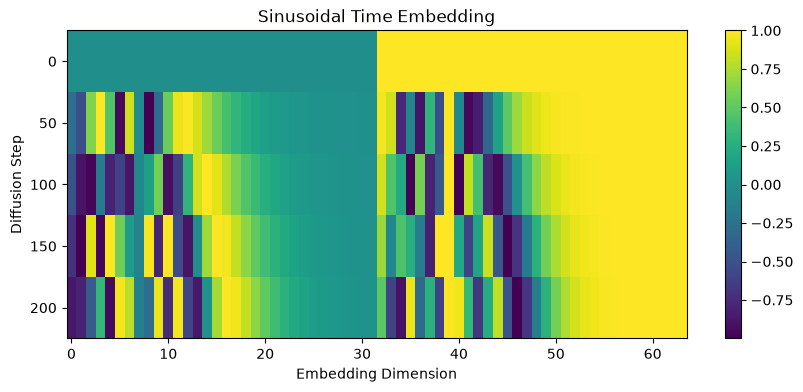

In [4]:
plt.figure(figsize=(10,4))

plt.imshow(
    embeddings.numpy(),
    aspect="auto",
    cmap="viridis"
)

plt.colorbar()

plt.yticks(
    range(5),
    ["0","50","100","150","200"]
)

plt.xlabel("Embedding Dimension")

plt.ylabel("Diffusion Step")

plt.title("Sinusoidal Time Embedding")

plt.show()

In [5]:
class ResidualBlock(tf.keras.layers.Layer):

    def __init__(self, channels):

        super().__init__()

        self.conv1 = tf.keras.layers.Conv2D(
            channels,
            3,
            padding="same"
        )

        self.bn1 = tf.keras.layers.BatchNormalization()

        self.conv2 = tf.keras.layers.Conv2D(
            channels,
            3,
            padding="same"
        )

        self.bn2 = tf.keras.layers.BatchNormalization()

        self.activation = tf.keras.layers.ReLU()

        self.time_dense = tf.keras.layers.Dense(channels)

    def call(self, x, t_embed=None, training=False):

        shortcut = x

        h = self.conv1(x)
        h = self.bn1(h, training=training)

        if t_embed is not None:

            t = self.time_dense(t_embed)

            t = tf.reshape(
                t,
                (-1,1,1,h.shape[-1])
            )

            h = h + t

        h = self.activation(h)

        h = self.conv2(h)

        h = self.bn2(h, training=training)

        out = self.activation(
            h + shortcut
        )

        return out

In [6]:
sample = tf.random.normal((1,32,32,64))

print("Input shape :", sample.shape)

Input shape : (1, 32, 32, 64)


In [7]:
block = ResidualBlock(64)

output_without = block(
    sample,
    training=False
)

print("Output shape (without time):",
      output_without.shape)

Output shape (without time): (1, 32, 32, 64)


c:\Users\Reaper\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'residual_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [8]:
t = tf.constant([100])

t_embed = time_embedding(t)

output_with = block(
    sample,
    t_embed=t_embed,
    training=False
)

print("Output shape (with time):",
      output_with.shape)

Output shape (with time): (1, 32, 32, 64)


In [9]:
print("Feature map before block :", sample.shape)
print("Feature map after block  :", output_with.shape)

Feature map before block : (1, 32, 32, 64)
Feature map after block  : (1, 32, 32, 64)


In [10]:
difference = tf.reduce_mean(
    tf.abs(output_with - output_without)
)

print("Mean Absolute Difference:",
      difference.numpy())

Mean Absolute Difference: 0.18383698


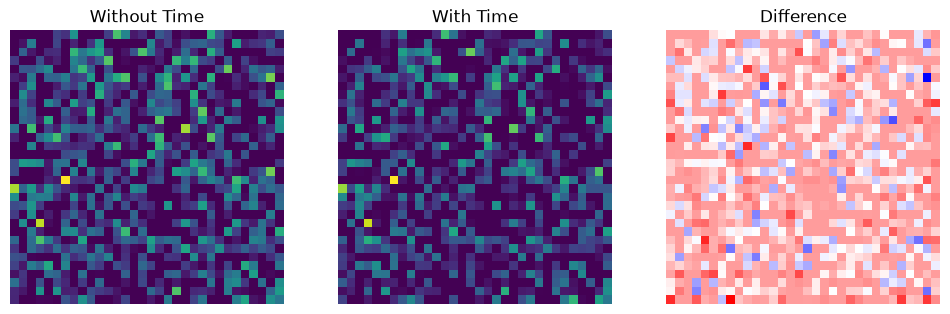

In [11]:
fig, ax = plt.subplots(1,3,figsize=(12,4))

ax[0].imshow(
    output_without[0,:,:,0],
    cmap="viridis"
)
ax[0].set_title("Without Time")

ax[1].imshow(
    output_with[0,:,:,0],
    cmap="viridis"
)
ax[1].set_title("With Time")

ax[2].imshow(
    output_with[0,:,:,0] -
    output_without[0,:,:,0],
    cmap="bwr"
)
ax[2].set_title("Difference")

for a in ax:
    a.axis("off")

plt.show()